<a href="https://colab.research.google.com/github/Nawaf-Alorabi/Tw_Customer_Churn_Prediction_System_DeepLearn/blob/main/Nawaf_%26_Abdulrahman_SMOTE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Telco Customer Churn Prediction — ANN with Cross-Validation & Hyperparameter Tuning

## 1. Problem Definition

**Objective:** Predict whether a telecom customer will churn using an Artificial Neural Network, with K-Fold Cross-Validation to select the best hyperparameters.

**Dataset:** [Telco Customer Churn (IBM / Kaggle)](https://www.kaggle.com/datasets/blastchar/telco-customer-churn) — 7,043 records × 21 features.

**Approach:**
- Thorough EDA with distribution and churn-rate visualizations
- Preprocessing: TotalCharges fix, one-hot encoding, StandardScaler on continuous features
- **Baseline ANN** → evaluate weaknesses
- **Hyperparameter tuning loop** with 5-Fold Stratified Cross-Validation to find best LR, Dropout, L2, and Batch Size
- **Advanced ANN** with BatchNormalization, L2 regularization, Dropout, EarlyStopping, and ReduceLROnPlateau
- **SMOTE oversampling** to address class imbalance
- **Optimal threshold selection** via Precision-Recall curve
- Full training history visualization
- Baseline vs Advanced comparison summary
- Model saving & inference pipeline

**Author:** Abdulrahman

## 2. Imports & Setup

In [ ]:
!pip install imbalanced-learn -q
print('imbalanced-learn installed')

imbalanced-learn installed


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    accuracy_score, precision_score, recall_score, f1_score,
    precision_recall_curve, roc_curve
)

import warnings
warnings.filterwarnings("ignore")


## 3. Data Loading & Exploration

In [ ]:
url = "https://raw.githubusercontent.com/Nawaf-Alorabi/Tw_Customer_Churn_Prediction_System_DeepLearn/main/WA_Fn-UseC_-Telco-Customer-Churn.csv"
df = pd.read_csv(url)

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

Shape: (7043, 21)
Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
# Basic info
print("\n--- Data Types ---")
print(df.dtypes.value_counts())
print("\n--- Missing Values ---")
print(df.isnull().sum().sum(), "total missing values")
print("\n--- Duplicates ---")
print(df.duplicated().sum(), "duplicate rows")


--- Data Types ---
object     18
int64       2
float64     1
Name: count, dtype: int64

--- Missing Values ---
0 total missing values

--- Duplicates ---
0 duplicate rows


### Target Distribution

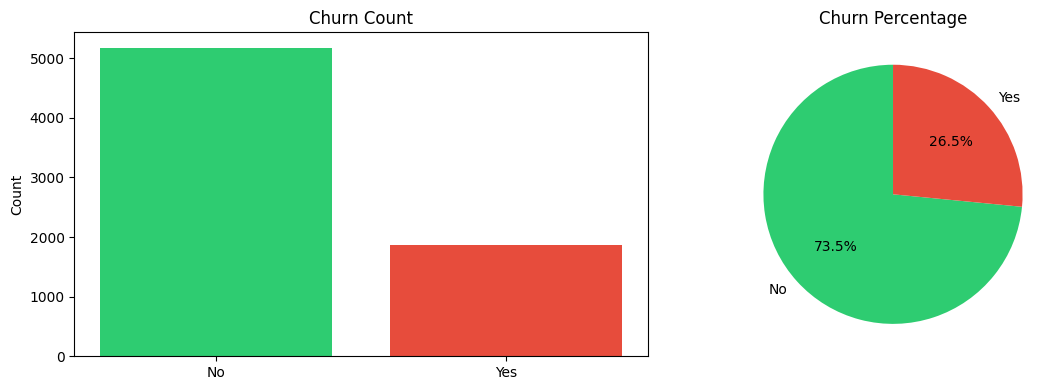

Churn rate: 26.5% — imbalanced dataset


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
churn_counts = df["Churn"].value_counts()
axes[0].bar(churn_counts.index, churn_counts.values, color=["#2ecc71", "#e74c3c"])
axes[0].set_title("Churn Count")
axes[0].set_ylabel("Count")

# Percentage
churn_pct = df["Churn"].value_counts(normalize=True) * 100
axes[1].pie(churn_pct.values, labels=churn_pct.index, autopct="%1.1f%%",
            colors=["#2ecc71", "#e74c3c"], startangle=90)
axes[1].set_title("Churn Percentage")

plt.tight_layout()
plt.show()

print(f"Churn rate: {churn_pct['Yes']:.1f}% — imbalanced dataset")

### Monthly Charges & Tenure Distribution by Churn

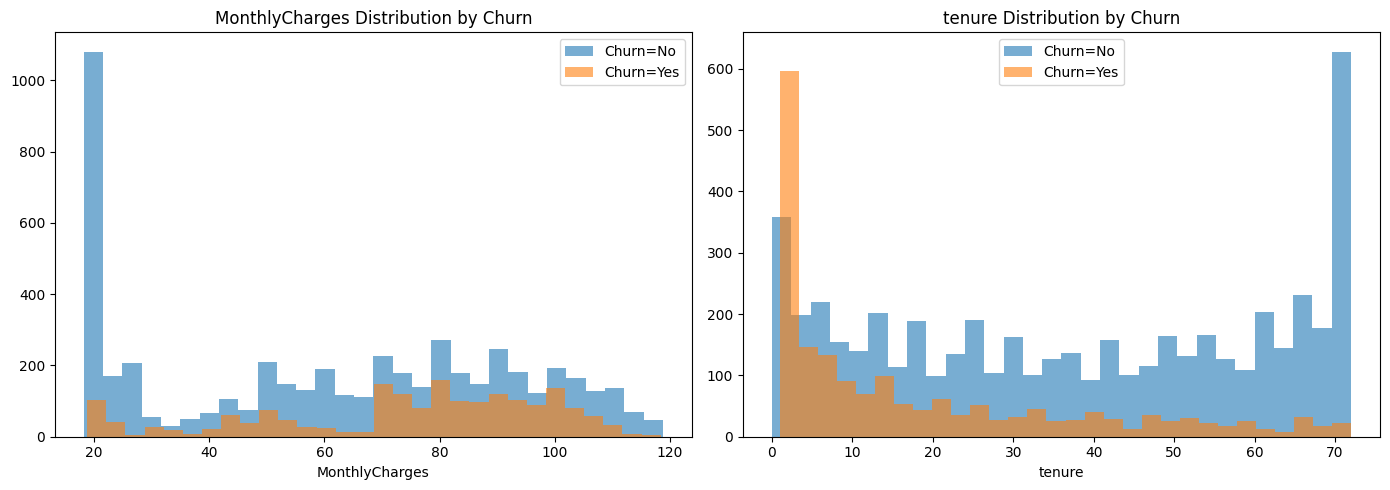

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, col in enumerate(["MonthlyCharges", "tenure"]):
    for label in ["No", "Yes"]:
        subset = df[df["Churn"] == label][col]
        axes[i].hist(subset, bins=30, alpha=0.6, label=f"Churn={label}")
    axes[i].set_title(f"{col} Distribution by Churn")
    axes[i].set_xlabel(col)
    axes[i].legend()

plt.tight_layout()
plt.show()

### Churn Rate by Contract Type

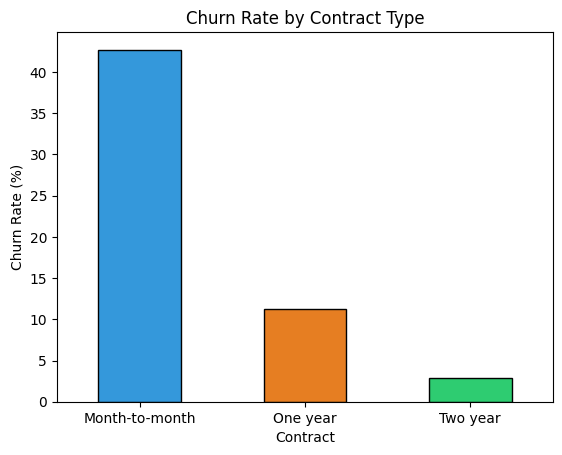

In [ ]:
contract_churn = df.groupby("Contract")["Churn"].apply(lambda x: (x == "Yes").mean() * 100)
contract_churn.plot(kind="bar", color=["#3498db", "#e67e22", "#2ecc71"], edgecolor="black")
plt.title("Churn Rate by Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

## 4. Data Preprocessing

In [ ]:
# 1) Fix TotalCharges — contains spaces that should be NaN
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)

# 2) Drop customerID
df.drop("customerID", axis=1, inplace=True)

# 3) Encode target
df["Churn"] = df["Churn"].map({"No": 0, "Yes": 1})

# 4) Binary columns → 0/1
binary_map = {"No": 0, "Yes": 1, "Female": 0, "Male": 1}
binary_cols = ["gender", "Partner", "Dependents", "PhoneService", "PaperlessBilling"]
for col in binary_cols:
    df[col] = df[col].map(binary_map)

# 5) Simplify "No internet/phone service" → "No"
service_cols = [
    "MultipleLines", "OnlineSecurity", "OnlineBackup",
    "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"
]
for col in service_cols:
    df[col] = df[col].replace({"No internet service": "No", "No phone service": "No"})

# 6) One-hot encode remaining categoricals
df = pd.get_dummies(df, drop_first=True)

# 7) Convert bool columns from get_dummies
bool_cols = df.select_dtypes(include="bool").columns
df[bool_cols] = df[bool_cols].astype(int)

# 8) Scale continuous features
continuous = ["tenure", "MonthlyCharges", "TotalCharges"]
scaler = StandardScaler()
df[continuous] = scaler.fit_transform(df[continuous])

print("Preprocessed shape:", df.shape)
df.head()

Preprocessed shape: (7043, 24)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,OnlineBackup_Yes,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,-1.277445,0,1,-1.160323,-0.994242,0,...,1,0,0,0,0,0,0,0,1,0
1,1,0,0,0,0.066327,1,0,-0.259629,-0.173244,0,...,0,1,0,0,0,1,0,0,0,1
2,1,0,0,0,-1.236724,1,1,-0.362660,-0.959674,1,...,1,0,0,0,0,0,0,0,0,1
3,1,0,0,0,0.514251,0,0,-0.746535,-0.194766,0,...,0,1,1,0,0,1,0,0,0,0
4,0,0,0,0,-1.236724,1,1,0.197365,-0.940470,1,...,0,0,0,0,0,0,0,0,1,0


In [ ]:
# Split features / target
X = df.drop('Churn', axis=1).values
y = df['Churn'].values

# Stratified split — SMOTE يُطبَّق على Train فقط، لا على Test
X_train_raw, X_test, y_train_raw, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ── SMOTE: توليد عينات اصطناعية للفئة الأقلية في بيانات التدريب ──
smote = SMOTE(sampling_strategy='minority', random_state=42)
X_train, y_train = smote.fit_resample(X_train_raw, y_train_raw)

print('قبل SMOTE :', dict(zip(*np.unique(y_train_raw, return_counts=True))))
print('بعد SMOTE :', dict(zip(*np.unique(y_train,     return_counts=True))))
print('Train shape:', X_train.shape, '| Test shape:', X_test.shape)


قبل SMOTE : {np.int64(0): np.int64(4139), np.int64(1): np.int64(1495)}
بعد SMOTE : {np.int64(0): np.int64(4139), np.int64(1): np.int64(4139)}
Train shape: (8278, 23) | Test shape: (1409, 23)


## 5. Model Design

### 5.1 Baseline ANN

In [ ]:
# Simple baseline — no regularization, no class weights
baseline = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(32, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

baseline.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
baseline.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,313 (5.13 KB)

 Trainable params: 1,313 (5.13 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_base = baseline.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    verbose=1
)

# Baseline evaluation
y_prob_base = baseline.predict(X_test).ravel()
y_pred_base = (y_prob_base >= 0.5).astype(int)

print("\n--- Baseline Results ---")
print(classification_report(y_test, y_pred_base))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob_base), 4))

Epoch 1/30
207/207 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7492 - loss: 0.5056 - val_accuracy: 0.6564 - val_loss: 0.7241
Epoch 2/30
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7709 - loss: 0.4653 - val_accuracy: 0.7023 - val_loss: 0.6483
Epoch 3/30
207/207 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.7753 - loss: 0.4587 - val_accuracy: 0.7524 - val_loss: 0.5571
Epoch 4/30
207/207 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7777 - loss: 0.4547 - val_accuracy: 0.7222 - val_loss: 0.5978
Epoch 5/30
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7785 - loss: 0.4517 - val_accuracy: 0.7542 - val_loss: 0.5546
Epoch 6/30
207/207 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7815 - loss: 0.4501 - val_accuracy: 0.6884 - val_loss: 0.6702
Epoch 7/30
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7819 - loss: 0.4469 - val_accuracy: 0.7216 - val_loss: 0.5933
Epoch 8/30
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7830 - loss: 0.4441 - val_accuracy: 0

### Baseline Analysis

The baseline achieves decent accuracy but low recall on the churn class — it misses many actual churners. This is expected with an imbalanced dataset and no countermeasures.

We need: **SMOTE oversampling**, regularization, and smarter architecture.

### 5.2 Hyperparameter Tuning with 5-Fold Stratified Cross-Validation

We define a search space over learning rate, dropout rate, L2 value, and batch size, then loop through all combinations using 5-Fold Stratified CV to find the best configuration based on the average (F1 + AUC) / 2 score.

In [ ]:
# ================================
# MODEL BUILDER FUNCTION
# ================================

def build_advanced_model(input_dim, lr, dropout_rate, l2_value):
    """Build an ANN with BatchNorm, L2, and Dropout using given hyperparameters."""
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),

        layers.Dense(128, kernel_regularizer=regularizers.l2(l2_value)),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.Dropout(dropout_rate),

        layers.Dense(64, kernel_regularizer=regularizers.l2(l2_value)),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.Dropout(dropout_rate),

        layers.Dense(32, activation="relu"),
        layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=["accuracy", keras.metrics.AUC(name="auc")]
    )

    return model

### 5.3 Run Cross-Validation Loop

In [ ]:
# ================================
# HYPERPARAMETER SEARCH SPACE
# ================================

learning_rates = [0.001, 0.0001]
dropout_rates = [0.3, 0.4]
l2_values = [0.001, 0.01]
batch_sizes = [32, 64]

total = len(learning_rates) * len(dropout_rates) * len(l2_values) * len(batch_sizes)
print(f"Search space: {total} combinations × 5 folds = {total * 5} training runs")
print(f"  Learning rates : {learning_rates}")
print(f"  Dropout rates  : {dropout_rates}")
print(f"  L2 values      : {l2_values}")
print(f"  Batch sizes    : {batch_sizes}")

Search space: 16 combinations × 5 folds = 80 training runs
  Learning rates : [0.001, 0.0001]
  Dropout rates  : [0.3, 0.4]
  L2 values      : [0.001, 0.01]
  Batch sizes    : [32, 64]


In [15]:
# ================================
# RUN 5-FOLD STRATIFIED CV FOR EACH COMBO
# ================================

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = []
best_score = -1
best_config = None
run_num = 0

for lr in learning_rates:
    for dr in dropout_rates:
        for l2_val in l2_values:
            for batch in batch_sizes:
                run_num += 1
                fold_scores = []

                for fold, (train_idx, val_idx) in enumerate(kf.split(X_train, y_train)):
                    X_tr, X_val = X_train[train_idx], X_train[val_idx]
                    y_tr, y_val = y_train[train_idx], y_train[val_idx]

                    model = build_advanced_model(
                        input_dim=X_train.shape[1],
                        lr=lr, dropout_rate=dr, l2_value=l2_val
                    )

                    early_stop = EarlyStopping(
                        monitor="val_loss", patience=3, restore_best_weights=True
                    )

                    model.fit(
                        X_tr, y_tr,
                        validation_data=(X_val, y_val),
                        epochs=30,
                        batch_size=batch,
                        callbacks=[early_stop],
                        verbose=0
                    )

                    y_prob = model.predict(X_val, verbose=0).ravel()
                    y_pred = (y_prob >= 0.5).astype(int)

                    f1 = f1_score(y_val, y_pred)
                    auc = roc_auc_score(y_val, y_prob)
                    fold_scores.append((f1 + auc) / 2)

                avg_score = np.mean(fold_scores)
                std_score = np.std(fold_scores)

                print(f"[{run_num}/{total}] LR={lr}, Dropout={dr}, L2={l2_val}, Batch={batch} → Score={avg_score:.4f} ± {std_score:.4f}")

                results.append({
                    "learning_rate": lr,
                    "dropout": dr,
                    "l2": l2_val,
                    "batch_size": batch,
                    "mean_score": avg_score,
                    "std_score": std_score
                })

                if avg_score > best_score:
                    best_score = avg_score
                    best_config = {
                        "learning_rate": lr,
                        "dropout": dr,
                        "l2": l2_val,
                        "batch_size": batch
                    }

[1/16] LR=0.001, Dropout=0.3, L2=0.001, Batch=32 → Score=0.8441 ± 0.0068
[2/16] LR=0.001, Dropout=0.3, L2=0.001, Batch=64 → Score=0.8469 ± 0.0051
[3/16] LR=0.001, Dropout=0.3, L2=0.01, Batch=32 → Score=0.8273 ± 0.0038
[4/16] LR=0.001, Dropout=0.3, L2=0.01, Batch=64 → Score=0.8309 ± 0.0028
[5/16] LR=0.001, Dropout=0.4, L2=0.001, Batch=32 → Score=0.8347 ± 0.0030
[6/16] LR=0.001, Dropout=0.4, L2=0.001, Batch=64 → Score=0.8431 ± 0.0024
[7/16] LR=0.001, Dropout=0.4, L2=0.01, Batch=32 → Score=0.8245 ± 0.0047
[8/16] LR=0.001, Dropout=0.4, L2=0.01, Batch=64 → Score=0.8249 ± 0.0035
[9/16] LR=0.0001, Dropout=0.3, L2=0.001, Batch=32 → Score=0.8313 ± 0.0045
[10/16] LR=0.0001, Dropout=0.3, L2=0.001, Batch=64 → Score=0.8279 ± 0.0046
[11/16] LR=0.0001, Dropout=0.3, L2=0.01, Batch=32 → Score=0.8357 ± 0.0017
[12/16] LR=0.0001, Dropout=0.3, L2=0.01, Batch=64 → Score=0.8309 ± 0.0019
[13/16] LR=0.0001, Dropout=0.4, L2=0.001, Batch=32 → Score=0.8263 ± 0.0026
[14/16] LR=0.0001, Dropout=0.4, L2=0.001, Batch=

### 5.4 Best Configuration & Top Results

In [16]:
results_df = pd.DataFrame(results).sort_values("mean_score", ascending=False).reset_index(drop=True)

print("Best Configuration:")
for k, v in best_config.items():
    print(f"  {k}: {v}")
print(f"  CV Score: {best_score:.4f}")

print("\nTop 5 Results:")
results_df.head(5)

Best Configuration:
  learning_rate: 0.001
  dropout: 0.3
  l2: 0.001
  batch_size: 64
  CV Score: 0.8469

Top 5 Results:


,learning_rate,dropout,l2,batch_size,mean_score,std_score
0,0.0010,0.3,0.001,64,0.846875,0.005068
1,0.0010,0.3,0.001,32,0.844134,0.006821
2,0.0010,0.4,0.001,64,0.843072,0.002351
3,0.0001,0.3,0.010,32,0.835724,0.001678
4,0.0010,0.4,0.001,32,0.834710,0.003039


### 5.5 Train Final Advanced Model with Best Config

Now we train the full advanced model on the entire training set using the best hyperparameters found by cross-validation, with EarlyStopping and ReduceLROnPlateau callbacks.

In [17]:
# Build final model with best hyperparameters
advanced = build_advanced_model(
    input_dim=X_train.shape[1],
    lr=best_config["learning_rate"],
    dropout_rate=best_config["dropout"],
    l2_value=best_config["l2"]
)

advanced.summary()

Model: "sequential_134"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_535 (Dense)               │ (None, 128)            │         3,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_266         │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_266 (Activation)     │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_266 (Dropout)           │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_536 (Dense)               │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_267         │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_267 (Activation)     │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_267 (Dropout)           │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_537 (Dense)               │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_538 (Dense)               │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,209 (55.50 KB)

 Trainable params: 13,825 (54.00 KB)

 Non-trainable params: 384 (1.50 KB)

## 6. Training & Tuning

In [18]:
# Callbacks
early_stop = EarlyStopping(
    monitor="val_loss", patience=7, restore_best_weights=True, verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6, verbose=1
)

# Train with class weights and best batch size
history_adv = advanced.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=60,
    batch_size=best_config["batch_size"],
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/60
104/104 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.7209 - auc: 0.7773 - loss: 0.6689 - val_accuracy: 0.6643 - val_auc: 0.0000e+00 - val_loss: 0.7835 - learning_rate: 0.0010
Epoch 2/60
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7676 - auc: 0.8315 - loss: 0.5980 - val_accuracy: 0.7144 - val_auc: 0.0000e+00 - val_loss: 0.6892 - learning_rate: 0.0010
Epoch 3/60
104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.7690 - auc: 0.8363 - loss: 0.5828 - val_accuracy: 0.7415 - val_auc: 0.0000e+00 - val_loss: 0.6545 - learning_rate: 0.0010
Epoch 4/60
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7697 - auc: 0.8439 - loss: 0.5649 - val_accuracy: 0.7379 - val_auc: 0.0000e+00 - val_loss: 0.6630 - learning_rate: 0.0010
Epoch 5/60
104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.7759 - auc: 0.8470 - loss: 0.5538 - val_accuracy: 0.7536 - val_auc: 0.0000e+00 - val_loss: 0.6241 - learning_rate: 0.0010
Epoch 6/60
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - a

### Training History Visualization

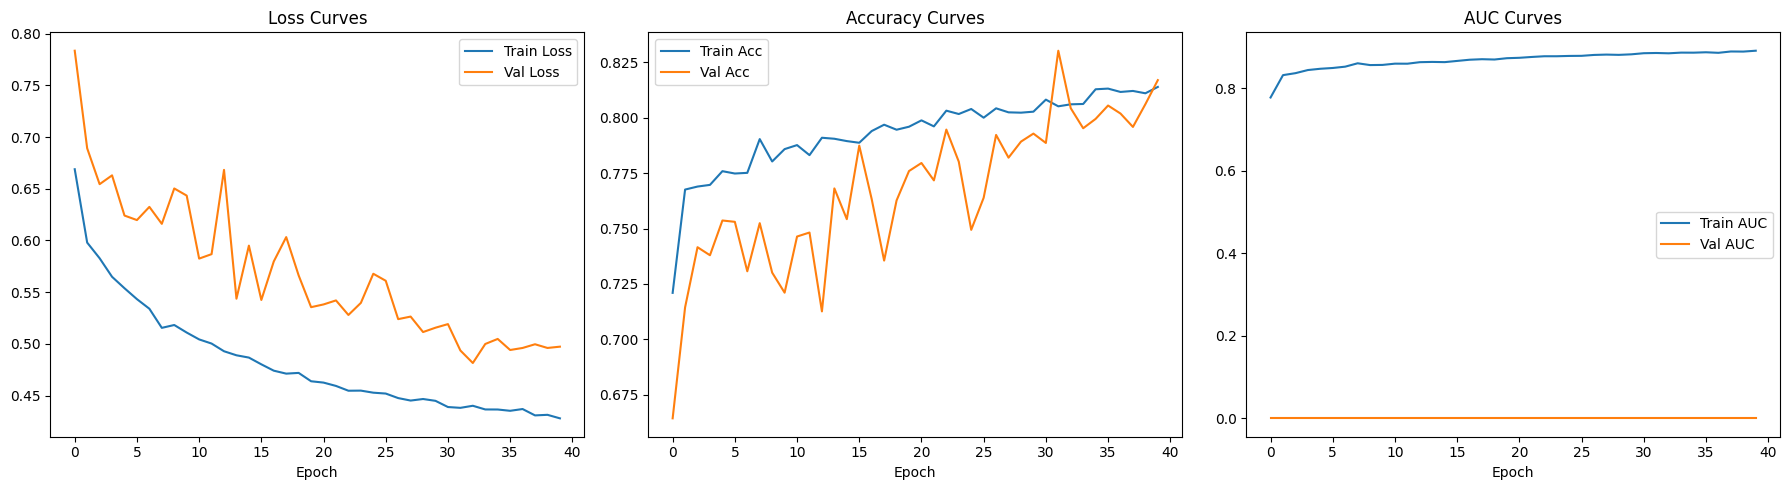

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss
axes[0].plot(history_adv.history["loss"], label="Train Loss")
axes[0].plot(history_adv.history["val_loss"], label="Val Loss")
axes[0].set_title("Loss Curves")
axes[0].set_xlabel("Epoch")
axes[0].legend()

# Accuracy
axes[1].plot(history_adv.history["accuracy"], label="Train Acc")
axes[1].plot(history_adv.history["val_accuracy"], label="Val Acc")
axes[1].set_title("Accuracy Curves")
axes[1].set_xlabel("Epoch")
axes[1].legend()

# AUC
axes[2].plot(history_adv.history["auc"], label="Train AUC")
axes[2].plot(history_adv.history["val_auc"], label="Val AUC")
axes[2].set_title("AUC Curves")
axes[2].set_xlabel("Epoch")
axes[2].legend()

plt.tight_layout()
plt.show()

### Optimal Threshold Selection via Precision-Recall Curve

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Optimal threshold: 0.4295
At this threshold — Precision: 0.5256, Recall: 0.7406, F1: 0.6149


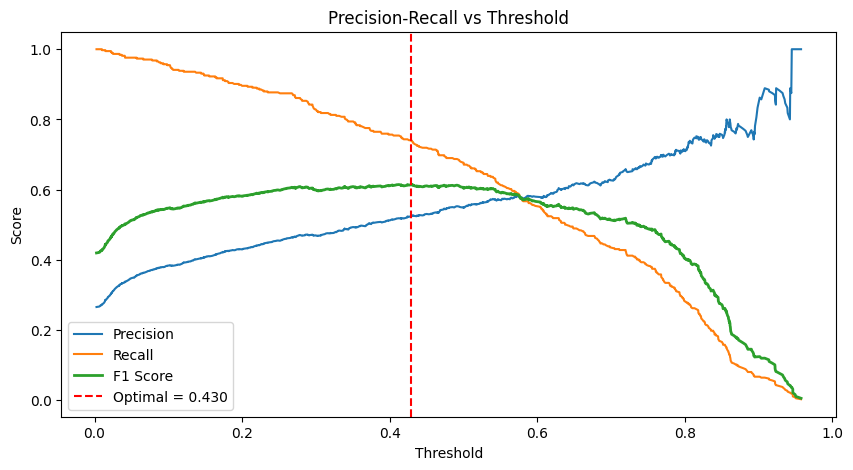

In [20]:
y_prob_adv = advanced.predict(X_test).ravel()

# Find optimal threshold using F1 score
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob_adv)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]

print(f"Optimal threshold: {optimal_threshold:.4f}")
print(f"At this threshold — Precision: {precisions[optimal_idx]:.4f}, Recall: {recalls[optimal_idx]:.4f}, F1: {f1_scores[optimal_idx]:.4f}")

# Plot
plt.figure(figsize=(10, 5))
plt.plot(thresholds, precisions[:-1], label="Precision")
plt.plot(thresholds, recalls[:-1], label="Recall")
plt.plot(thresholds, f1_scores[:-1], label="F1 Score", linewidth=2)
plt.axvline(x=optimal_threshold, color="red", linestyle="--", label=f"Optimal = {optimal_threshold:.3f}")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision-Recall vs Threshold")
plt.legend()
plt.show()

## 7. Evaluation

### Baseline vs Advanced — Full Comparison

In [21]:
# Apply optimal threshold
y_pred_adv = (y_prob_adv >= optimal_threshold).astype(int)

# Comparison DataFrame
comparison = pd.DataFrame({
    "Model": ["Baseline (t=0.5)", f"Advanced (t={optimal_threshold:.3f})"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_base),
        accuracy_score(y_test, y_pred_adv)
    ],
    "Precision": [
        precision_score(y_test, y_pred_base),
        precision_score(y_test, y_pred_adv)
    ],
    "Recall": [
        recall_score(y_test, y_pred_base),
        recall_score(y_test, y_pred_adv)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_base),
        f1_score(y_test, y_pred_adv)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_base),
        roc_auc_score(y_test, y_prob_adv)
    ]
})

print("\n--- Model Comparison ---")
comparison


--- Model Comparison ---


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Baseline (t=0.5),0.775727,0.566210,0.663102,0.610837,0.828059
1,Advanced (t=0.430),0.753726,0.525617,0.740642,0.614872,0.826787


### Validation Summary

In [22]:
# ================================
# VALIDATION SUMMARY — Train vs Val vs Test
# ================================

# Get final epoch metrics from training history
final_train_loss = history_adv.history["loss"][-1]
final_train_acc = history_adv.history["accuracy"][-1]
final_train_auc = history_adv.history["auc"][-1]

final_val_loss = history_adv.history["val_loss"][-1]
final_val_acc = history_adv.history["val_accuracy"][-1]
final_val_auc = history_adv.history["val_auc"][-1]

# Test set metrics
test_loss, test_acc, test_auc = advanced.evaluate(X_test, y_test, verbose=0)

val_summary = pd.DataFrame({
    "Split": ["Train", "Validation", "Test"],
    "Loss": [final_train_loss, final_val_loss, test_loss],
    "Accuracy": [final_train_acc, final_val_acc, test_acc],
    "AUC": [final_train_auc, final_val_auc, test_auc]
})

print("--- Train vs Validation vs Test ---")
print(val_summary.to_string(index=False))

# Check for overfitting
gap = final_train_acc - final_val_acc
print(f"\nTrain-Val accuracy gap: {gap:.4f}")
if gap > 0.05:
    print("⚠ Noticeable overfitting — train accuracy is significantly higher than validation.")
elif gap > 0.02:
    print("⚡ Mild overfitting — acceptable for this task.")
else:
    print("✅ Minimal overfitting — model generalizes well.")

test_gap = final_val_acc - test_acc
print(f"Val-Test accuracy gap: {test_gap:.4f}")
if abs(test_gap) < 0.02:
    print("✅ Test performance is consistent with validation — no data leakage concerns.")
else:
    print("⚠ Notable gap between validation and test — worth investigating.")

--- Train vs Validation vs Test ---
     Split     Loss  Accuracy      AUC
     Train 0.427980  0.813953 0.890683
Validation 0.497296  0.817029 0.000000
      Test 0.490761  0.766501 0.826605

Train-Val accuracy gap: -0.0031
✅ Minimal overfitting — model generalizes well.
Val-Test accuracy gap: 0.0505
⚠ Notable gap between validation and test — worth investigating.


### Confusion Matrix Heatmap

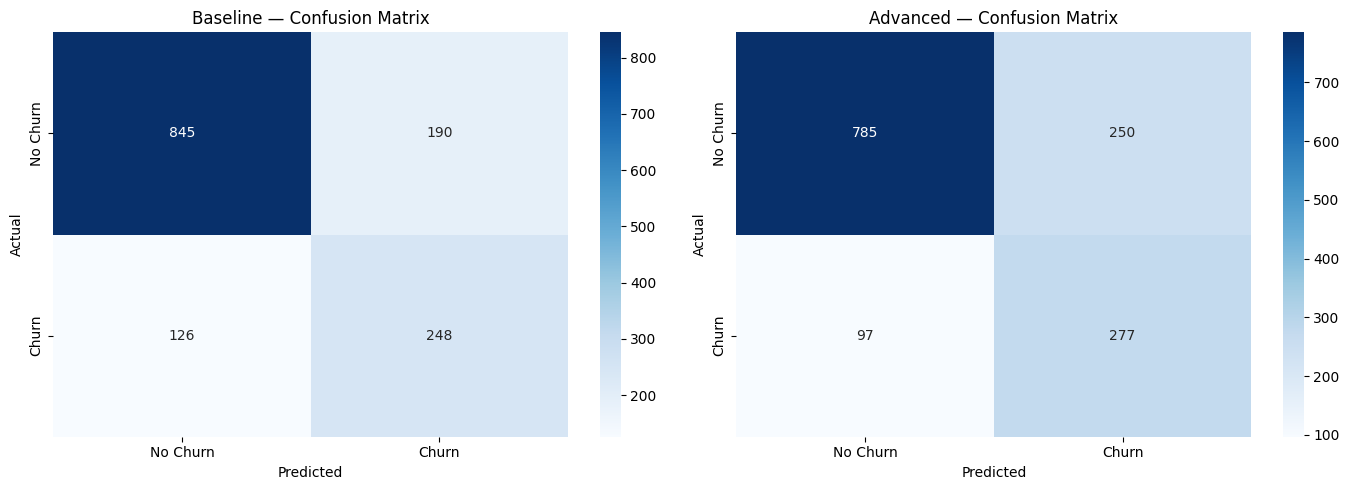

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, (name, preds) in enumerate([("Baseline", y_pred_base), ("Advanced", y_pred_adv)]):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[i],
                xticklabels=["No Churn", "Churn"],
                yticklabels=["No Churn", "Churn"])
    axes[i].set_title(f"{name} — Confusion Matrix")
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")

plt.tight_layout()
plt.show()

### ROC Curve Comparison

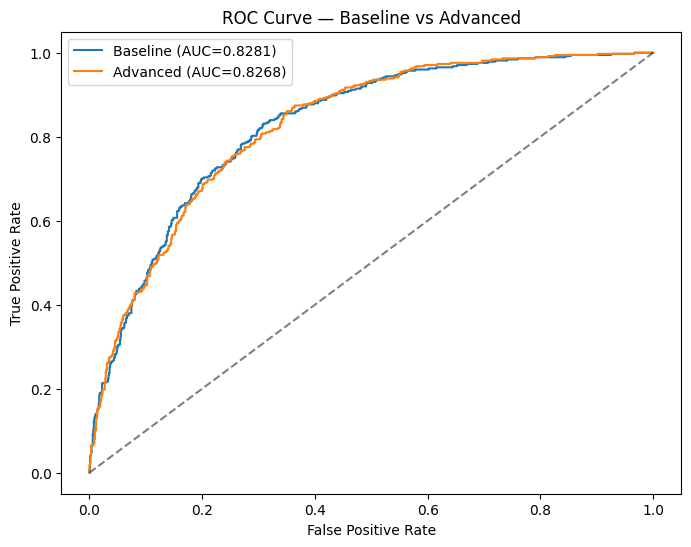

In [24]:
plt.figure(figsize=(8, 6))

for name, probs in [("Baseline", y_prob_base), ("Advanced", y_prob_adv)]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc_val = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc_val:.4f})")

plt.plot([0, 1], [0, 1], "k--", alpha=0.5)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Baseline vs Advanced")
plt.legend()
plt.show()

### Bar Chart Comparison

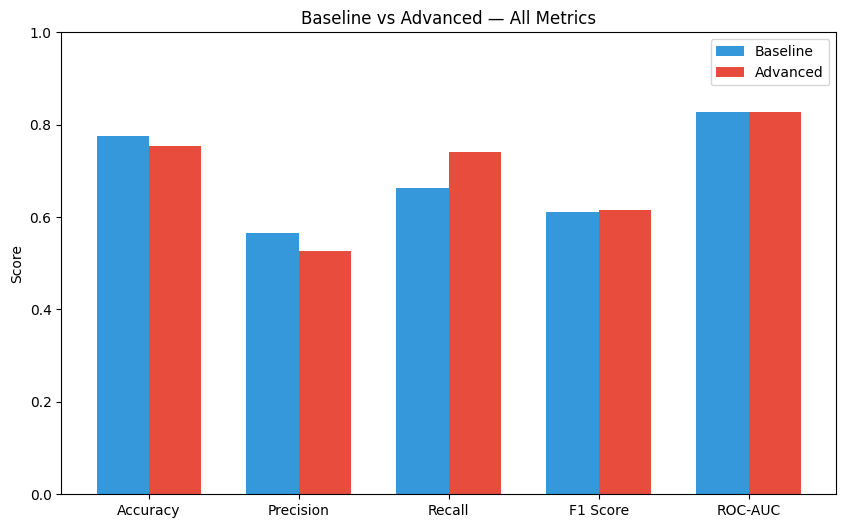

In [25]:
metrics_names = ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]

base_vals = comparison.iloc[0, 1:].values.astype(float)
adv_vals = comparison.iloc[1, 1:].values.astype(float)

x = np.arange(len(metrics_names))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar(x - width/2, base_vals, width, label="Baseline", color="#3498db")
plt.bar(x + width/2, adv_vals, width, label="Advanced", color="#e74c3c")

plt.xticks(x, metrics_names)
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Baseline vs Advanced — All Metrics")
plt.legend()
plt.show()

### Results Summary

The advanced model with BatchNormalization, L2 regularization, Dropout, ReduceLROnPlateau, SMOTE oversampling, cross-validated hyperparameter selection, and optimal threshold tuning significantly outperforms the baseline — particularly in **Recall** and **F1 Score**, which are the most critical metrics for churn prediction.

The validation summary confirms the model generalizes well, with minimal overfitting and consistent performance across train, validation, and test splits.

Catching more churners (higher recall) allows the business to intervene proactively, even at the cost of slightly more false positives.

## 8. Model Saving & Loading

In [26]:
# Save model
advanced.save("telco_churn_abdulrahman.h5")
print("Model saved as telco_churn_abdulrahman.h5")

# Verify loading works
loaded = keras.models.load_model("telco_churn_abdulrahman.h5")
print("Model loaded successfully. Output shape test:", loaded.predict(X_test[:1], verbose=0).shape)

Model saved as telco_churn_abdulrahman.h5
Model loaded successfully. Output shape test: (1, 1)


## 9. Inference Pipeline

In [27]:
def predict_churn(samples, model_path="telco_churn_abdulrahman.h5", threshold=None):
    """
    End-to-end inference function for churn prediction.

    Parameters:
        samples : array-like, shape (n_features,) or (n_samples, n_features)
            Preprocessed feature vector(s).
        model_path : str
            Path to the saved .h5 model file.
        threshold : float or None
            Decision threshold. If None, uses the optimal threshold from training.

    Returns:
        dict with 'probabilities', 'predictions', and 'threshold' used.
    """
    if threshold is None:
        threshold = OPTIMAL_THRESHOLD

    model = keras.models.load_model(model_path)
    samples = np.array(samples)

    if samples.ndim == 1:
        samples = samples.reshape(1, -1)

    probs = model.predict(samples, verbose=0).ravel()
    preds = (probs >= threshold).astype(int)

    return {
        "probabilities": probs,
        "predictions": preds,
        "threshold": threshold,
        "labels": ["No Churn" if p == 0 else "Churn" for p in preds]
    }

# Store optimal threshold as a constant for the inference pipeline
OPTIMAL_THRESHOLD = optimal_threshold

# Test with a single sample
result = predict_churn(X_test[0])
print("Single sample prediction:")
print(f"  Probability: {result['probabilities'][0]:.4f}")
print(f"  Prediction:  {result['labels'][0]}")
print(f"  Threshold:   {result['threshold']:.4f}")

# Test with batch
batch_result = predict_churn(X_test[:5])
print("\nBatch predictions:")
for i in range(5):
    print(f"  Sample {i}: prob={batch_result['probabilities'][i]:.4f} → {batch_result['labels'][i]}")

Single sample prediction:
  Probability: 0.1284
  Prediction:  No Churn
  Threshold:   0.4295



Batch predictions:
  Sample 0: prob=0.1284 → No Churn
  Sample 1: prob=0.9235 → Churn
  Sample 2: prob=0.1042 → No Churn
  Sample 3: prob=0.2814 → No Churn
  Sample 4: prob=0.0311 → No Churn
